In [4]:
%matplotlib inline

In [12]:
# Figure 1 data extraction (run notebook from the project root)
import json, os
import numpy as np

TRACK_M_JSON = "runs/pilot_v1_2_20260717_1247_qwen3_4b.json"
TRACK_P_JSON = "runs/redesign_R1_trackP_20260717_1535_qwen3_4b.json"

POSITION_MARKERS = ("raw_mass", "other_mass")
KEY_CANDIDATES = ("p_cond_t1", "p_t1", "p_yes", "p_binary", "p", "prob_t1", "p1")

def iter_position_probs(node, misses):
    # Recursively yield binary-conditioned p from position dicts.
    if isinstance(node, dict):
        if any(m in node for m in POSITION_MARKERS):
            for key in KEY_CANDIDATES:
                if key in node and isinstance(node[key], (int, float)):
                    yield float(node[key])
                    break
            else:
                misses[0] += 1
        for v in node.values():
            yield from iter_position_probs(v, misses)
    elif isinstance(node, list):
        for v in node:
            yield from iter_position_probs(v, misses)

def load_sat_values(path):
    with open(path) as f:
        record = json.load(f)
    misses = [0]
    probs = np.array(list(iter_position_probs(record, misses)), dtype=float)
    print(f"{os.path.basename(path)}: {len(probs)} positions, "
          f"{misses[0]} position dicts without a known prob key")
    return np.maximum(probs, 1.0 - probs)

sat_m = load_sat_values(TRACK_M_JSON)   # expect ~186 positions
sat_p = load_sat_values(TRACK_P_JSON)   # expect ~96 positions

pilot_v1_2_20260717_1247_qwen3_4b.json: 186 positions, 0 position dicts without a known prob key
redesign_R1_trackP_20260717_1535_qwen3_4b.json: 96 positions, 0 position dicts without a known prob key


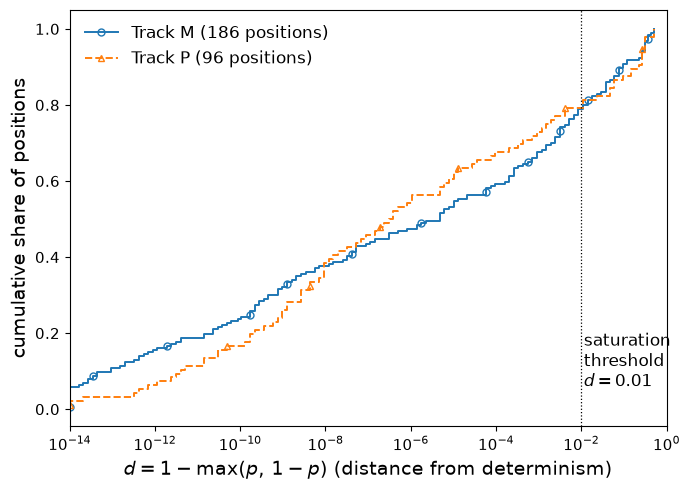

In [36]:
# Figure 1 final: ECDF of distance from determinism, Track M vs P
import numpy as np, matplotlib.pyplot as plt, os

CLIP = 1e-14
dM = np.clip(1.0 - sat_m, CLIP, None)   # sat_m/sat_p from the extraction cell
dP = np.clip(1.0 - sat_p, CLIP, None)

os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 5))
for d, label, ls, color, mk in [
        (dM, "Track M (186 positions)", "-", "tab:blue", "o"),
        (dP, "Track P (96 positions)", "--", "tab:orange", "^")]:
    xs = np.sort(d); ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.step(xs, ys, where="post", ls=ls, color=color, label=label, lw=1.4,
            marker=mk, markevery=15, markersize=5, markerfacecolor="none")
ax.axvline(1e-2, color="black", lw=0.9, ls=":")
ax.text(1.15e-2, 0.06, "saturation\nthreshold\n$d = 0.01$", fontsize=12)
ax.set_xscale("log"); ax.set_xlim(CLIP, 1)
ax.set_xlabel(r"$d = 1 - \max(p,\,1-p)$ (distance from determinism)", fontsize=14)
ax.set_ylabel("cumulative share of positions", fontsize=14)
ax.legend(fontsize=12, loc="upper left", frameon=False)
ax.tick_params(labelsize=11)
#ax.text(CLIP * 1.5, 0.97, r"values $\leq 10^{-14}$ clipped", fontsize=7, va="top")
fig.tight_layout()
fig.savefig("figures/fig1_saturation.pdf", bbox_inches="tight")
plt.show()

13 A/B items extracted


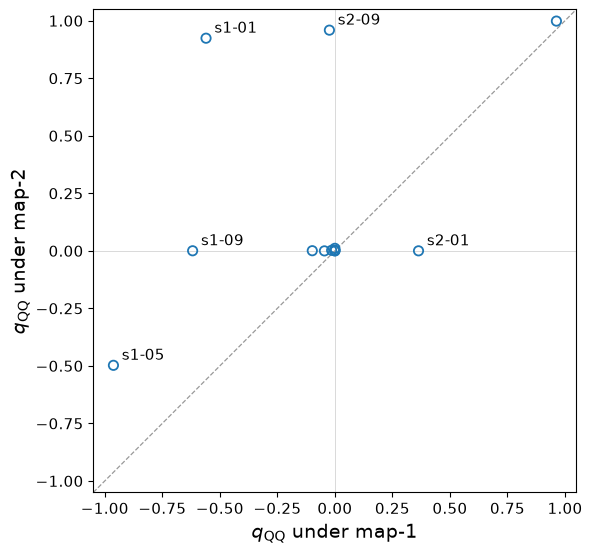

In [38]:
# Figure 2: label effect under counterbalancing (A/B items, Track M)
# q_QQ under map-1 vs map-2, read from the pilot audit record.
import json, os
import numpy as np
import matplotlib.pyplot as plt

TRACK_M_JSON = "runs/pilot_v1_2_20260717_1247_qwen3_4b.json"

with open(TRACK_M_JSON) as f:
    rec = json.load(f)

items, q_m1, q_m2 = [], [], []
for it in rec["results"]:
    if it.get("label_scheme") != "AB":
        continue
    items.append(it["id"])
    q_m1.append(float(it["mappings"]["map-1"]["point"]["q_QQ"]))
    q_m2.append(float(it["mappings"]["map-2"]["point"]["q_QQ"]))
q_m1, q_m2 = np.array(q_m1), np.array(q_m2)
print(f"{len(items)} A/B items extracted")

os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([-1.05, 1.05], [-1.05, 1.05], color="0.6", lw=0.9, ls="--", zorder=1)
ax.scatter(q_m1, q_m2, s=45, marker="o", facecolors="none",
           edgecolors="tab:blue", linewidths=1.3, zorder=2)
for x, y, it in zip(q_m1, q_m2, items):
    if abs(x - y) > 0.3:
        ax.annotate(it, (x, y), textcoords="offset points",
                    xytext=(6, 4), fontsize=11)
ax.axhline(0, color="0.85", lw=0.7, zorder=0)
ax.axvline(0, color="0.85", lw=0.7, zorder=0)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.set_xlabel(r"$q_{\mathrm{QQ}}$ under map-1", fontsize=14)
ax.set_ylabel(r"$q_{\mathrm{QQ}}$ under map-2", fontsize=14)
ax.tick_params(labelsize=11)
fig.tight_layout()
fig.savefig("figures/fig2_label_effect.pdf", bbox_inches="tight")
plt.show()